Fundamentals of Dynamics and Controls HW6

In [24]:
# imports
import sympy as sp
import numpy as np
import DynCon_Functions as dc
from IPython.display import display
from sympy import symbols, init_printing

Problem #1

In [25]:
x = sp.Symbol('x')
y = sp.Symbol('y')
z = sp.Symbol('z')
rho = sp.Symbol('rho')
V = sp.Symbol('V')
J_xx = sp.Symbol('J_{xx}')
J_yy = sp.Symbol('J_{yy}')
J_zz = sp.Symbol('J_{zz}')

expr_xx = rho*(y**2+z**2)
expr_yy = rho*(x**2+z**2)
expr_zz = rho*(x**2+y**2)
expr = expr_xx-expr_yy+expr_zz

display(sp.Eq(J_xx-J_yy+J_zz, sp.simplify(expr)))
print('\nBecause rho must be positive by definition and y^2 must be positive, then therefore:\n')
display(J_xx-J_yy+J_zz > 0)


Because rho must be positive by definition and y^2 must be positive, then therefore:



Problem #2

Total Angular Velocity Calculation

In [26]:
init_printing(use_unicode=True)
W = sp.symbols('Omega')
w = sp.symbols('omega')
theta = sp.symbols('theta')

w_ac = sp.Matrix([
    [0],
    [0],
    [W]
])
w_p = sp.Matrix([
    [w],
    [0],
    [0]
])

C_ac_p = sp.Matrix([
    [1, 0, 0],
    [0, sp.cos(theta), sp.sin(theta)],
    [0, -sp.sin(theta), sp.cos(theta)]
])

w_p_in_ac = C_ac_p @ w_p
w_total_ac = w_ac + w_p_in_ac

display(w_total_ac)

Moment of Inertia Calculations

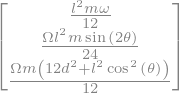

In [27]:
m, l, d = symbols('m, l, d', positive=True)

Ixx_p = sp.Rational(1, 12)*m*l**2
Iyy_p = sp.Integer(0)
Izz_p = sp.Rational(1, 12)*m*l**2

I_p = sp.Matrix([
    [Ixx_p, 0, 0],
    [0, Iyy_p, 0],
    [0, 0, Izz_p]
])

I_p_in_ac = C_ac_p @ I_p @ C_ac_p.T

r = sp.Matrix([d, 0, 0])

I_parraxes = m * ((r.dot(r))*sp.eye(3) - r*r.T)
I_p_in_ac += I_parraxes

h_p = sp.simplify(I_p_in_ac * w_total_ac)
display(sp.simplify(h_p))